# Sensitivity Analysis — Hidden Markov Model (HMM)

Reference model (from `HiddenMarkov_model.ipynb`):
- `n_components = 8`
- `covariance_type = 'full'`
- country-wise sequence lengths


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import adjusted_rand_score, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from IPython.display import display

try:
    from model_utils import load_clustering_data
except ModuleNotFoundError:
    from unsupervised.model_utils import load_clustering_data

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 120)


In [2]:
# -----------------------------
# Helpers
# -----------------------------
def resolve_existing_path(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return str(p)
    raise FileNotFoundError(f'None of these paths exist: {candidates}')


def hmm_param_count(n_states, n_features, covariance_type='full'):
    trans = n_states * (n_states - 1)
    start = n_states - 1
    means = n_states * n_features

    if covariance_type == 'full':
        cov = n_states * n_features * (n_features + 1) // 2
    elif covariance_type == 'diag':
        cov = n_states * n_features
    elif covariance_type == 'spherical':
        cov = n_states
    elif covariance_type == 'tied':
        cov = n_features * (n_features + 1) // 2
    else:
        raise ValueError(f'Unsupported covariance_type: {covariance_type}')

    return int(trans + start + means + cov)


def compute_information_criteria(log_likelihood, n_states, n_features, n_obs, covariance_type='full'):
    n_params = hmm_param_count(n_states, n_features, covariance_type)
    aic = -2 * log_likelihood + 2 * n_params
    bic = -2 * log_likelihood + n_params * np.log(n_obs)
    return aic, bic


def safe_cluster_metrics(X, labels):
    out = {'silhouette': np.nan, 'calinski_harabasz': np.nan, 'davies_bouldin': np.nan}
    uniq = np.unique(labels)
    if len(uniq) < 2:
        return out
    try:
        out['silhouette'] = silhouette_score(X, labels)
    except Exception:
        pass
    try:
        out['calinski_harabasz'] = calinski_harabasz_score(X, labels)
    except Exception:
        pass
    try:
        out['davies_bouldin'] = davies_bouldin_score(X, labels)
    except Exception:
        pass
    return out


def fit_single_hmm(X, lengths, n_states, covariance_type, n_iter, random_state):
    model = GaussianHMM(
        n_components=n_states,
        covariance_type=covariance_type,
        n_iter=n_iter,
        random_state=random_state,
        verbose=False,
    )
    model.fit(X, lengths)
    ll = model.score(X, lengths)
    labels = model.predict(X, lengths)
    post = model.predict_proba(X, lengths)
    return model, ll, labels, post


def fit_best_of_seeds(X, lengths, n_states, covariance_type, n_iter, seeds):
    best = None
    best_ll = -np.inf
    run_rows = []

    for seed in seeds:
        try:
            model, ll, labels, post = fit_single_hmm(X, lengths, n_states, covariance_type, n_iter, seed)
            run_rows.append({'seed': seed, 'log_likelihood': ll, 'error': None})
            if ll > best_ll:
                best_ll = ll
                best = (model, ll, labels, post, seed)
        except Exception as e:
            run_rows.append({'seed': seed, 'log_likelihood': np.nan, 'error': str(e)})

    runs_df = pd.DataFrame(run_rows)
    if best is None:
        raise RuntimeError('No successful HMM fit in provided seeds.')

    model, ll, labels, post, seed = best
    return {
        'model': model,
        'log_likelihood': ll,
        'labels': labels,
        'posterior': post,
        'seed': seed,
        'runs': runs_df,
    }


## Train Reference Model


In [3]:
N_STATES = 8
COV_TYPE = 'full'
N_ITER = 200
BASELINE_SEEDS = list(range(100, 120))

data_path = resolve_existing_path([
    '../data/milestone_ii_preprocessed_complete.pkl',
    'data/milestone_ii_preprocessed_complete.pkl',
])
features_path = resolve_existing_path([
    '../data/selected_features_complete.pkl',
    'data/selected_features_complete.pkl',
])

print(f'Using data path: {data_path}')
print(f'Using features path: {features_path}')

df_cluster, CLUSTER_FEATURES, X_scaled, scaler = load_clustering_data(data_path, features_path)

# Ensure country-wise contiguous sequences for HMM
df_cluster = df_cluster.sort_values(['country', 'date']).reset_index(drop=True)
X_scaled = scaler.transform(df_cluster[CLUSTER_FEATURES])
lengths = [len(g) for _, g in df_cluster.groupby('country', sort=True)]

baseline = fit_best_of_seeds(
    X_scaled, lengths,
    n_states=N_STATES, covariance_type=COV_TYPE, n_iter=N_ITER,
    seeds=BASELINE_SEEDS,
)

baseline_model = baseline['model']
baseline_ll = baseline['log_likelihood']
baseline_labels = baseline['labels']
baseline_post = baseline['posterior']
baseline_seed = baseline['seed']

n_obs, n_features = X_scaled.shape
baseline_aic, baseline_bic = compute_information_criteria(
    baseline_ll, N_STATES, n_features, n_obs, covariance_type=COV_TYPE
)
baseline_metrics = safe_cluster_metrics(X_scaled, baseline_labels)

baseline_state_counts = pd.Series(baseline_labels).value_counts().sort_index()
baseline_state_share = baseline_state_counts / len(baseline_labels)
baseline_conf = baseline_post.max(axis=1)

print(f'Baseline seed selected: {baseline_seed}')
print(f'Baseline LL:  {baseline_ll:.2f}')
print(f'Baseline AIC: {baseline_aic:.2f}')
print(f'Baseline BIC: {baseline_bic:.2f}')
print(f'Silhouette: {baseline_metrics["silhouette"]:.4f}')
print(f'Calinski-Harabasz: {baseline_metrics["calinski_harabasz"]:.2f}')
print(f'Davies-Bouldin: {baseline_metrics["davies_bouldin"]:.4f}')
print(f'Mean max posterior confidence: {baseline_conf.mean():.4f}')
print('State shares:')
print((baseline_state_share * 100).round(2).to_string())


Using data path: ..\data\milestone_ii_preprocessed_complete.pkl
Using features path: ..\data\selected_features_complete.pkl
Dataset shape: (1854, 239)
Date range: 2001-11 to 2018-12
Countries (9): ['Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'South Korea', 'UK', 'USA']

Clustering features (20):
   1. copper_lag_3mo
   2. comp_consumer_conf
   3. copper_lag_6mo
   4. cli
   5. copper
   6. real_rate_10yr
   7. vix_rolling_mean_12mo_lag_12mo
   8. real_gdp_log_6mo
   9. national_share_price_rolling_std_12mo
  10. yield_curve
  11. sahm_value_lag_12mo
  12. real_rate_10yr_lag_3mo
  13. epu_rolling_mean_12mo_lag_12mo
  14. vix_log_3mo
  15. gps_log_1mo
  16. gdp_qoq_growth_lag_12mo
  17. national_share_price_log_6mo
  18. cpi
  19. unemployment_rate_diff_6mo
  20. unemployment_rate_diff_1mo

Feature matrix: 1854 observations × 20 features
NaN rows dropped: 0


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.

Baseline seed selected: 109
Baseline LL:  -21908.23
Baseline AIC: 47622.46
Baseline BIC: 58136.73
Silhouette: 0.1131
Calinski-Harabasz: 198.06
Davies-Bouldin: 2.5713
Mean max posterior confidence: 0.9977
State shares:
0    15.86
1    24.76
2     3.88
3    18.55
4     8.04
5    14.19
6     7.34
7     7.39


### Baseline Reference Visuals


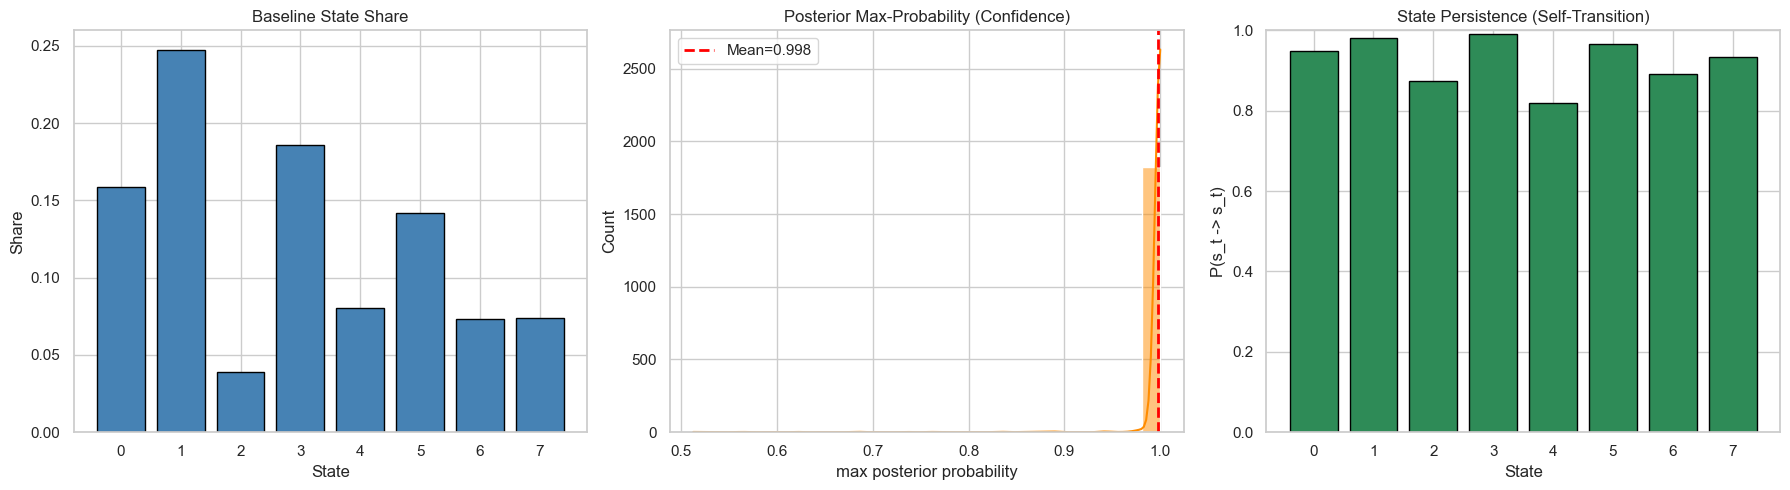

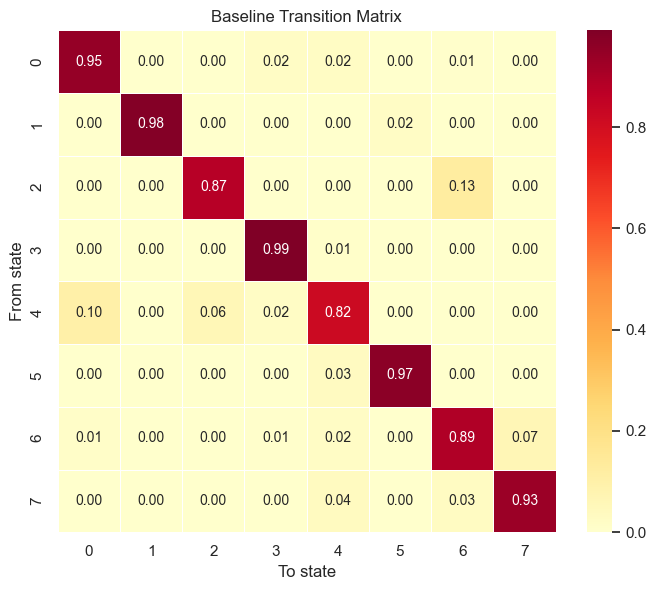

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# State share
axes[0].bar(baseline_state_share.index, baseline_state_share.values, color='steelblue', edgecolor='black')
axes[0].set_title('Baseline State Share')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Share')

# Confidence distribution
sns.histplot(baseline_conf, bins=25, kde=True, color='darkorange', ax=axes[1])
axes[1].axvline(baseline_conf.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={baseline_conf.mean():.3f}')
axes[1].set_title('Posterior Max-Probability (Confidence)')
axes[1].set_xlabel('max posterior probability')
axes[1].legend()

# Transition persistence
self_trans = np.diag(baseline_model.transmat_)
axes[2].bar(range(N_STATES), self_trans, color='seagreen', edgecolor='black')
axes[2].set_ylim(0, 1)
axes[2].set_title('State Persistence (Self-Transition)')
axes[2].set_xlabel('State')
axes[2].set_ylabel('P(s_t -> s_t)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
sns.heatmap(baseline_model.transmat_, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Baseline Transition Matrix')
plt.xlabel('To state')
plt.ylabel('From state')
plt.tight_layout()
plt.show()


### Baseline Summary (Result + Meaning)
- **Log-likelihood / AIC / BIC** measure overall fit vs complexity. The baseline (seed `109`) has **LL = -21,908.23**, **AIC = 47,622.46**, **BIC = 58,136.73** and is used as the reference point for all sensitivity tests.
- **Silhouette / CH / DB** summarize geometric separation of inferred states: **silhouette = 0.113**, **CH = 198.06**, **DB = 2.571**. For HMM, these are secondary diagnostics (HMM optimizes sequence likelihood, not cluster compactness).
- **State-share output** indicates class balance: largest is **State 1 = 24.76%**, smallest is **State 2 = 3.88%** (about **6.37x** imbalance), so rare-state interpretation should be cautious.
- **Max-posterior confidence** is the decoding certainty; mean **0.9977** indicates most points are assigned to one state with very high probability.


## 1. One-at-a-Time (OAT) Feature Perturbation



In [4]:
# Rank features by between-state variance in HMM means (proxy for state-separation influence)
mean_var = pd.Series(baseline_model.means_.var(axis=0), index=CLUSTER_FEATURES)
top_features = mean_var.sort_values(ascending=False).head(10).index.tolist()

perturbation_levels = {'mean': 0, '-2 sigma': -2, '-1 sigma': -1, '+1 sigma': 1, '+2 sigma': 2}

oat_rows = []
for feat in top_features:
    j = CLUSTER_FEATURES.index(feat)
    feat_mean = X_scaled[:, j].mean()
    feat_std = X_scaled[:, j].std()

    for level_name, n_sigma in perturbation_levels.items():
        X_pert = X_scaled.copy()
        X_pert[:, j] = feat_mean + n_sigma * feat_std

        labels_pert = baseline_model.predict(X_pert, lengths)
        post_pert = baseline_model.predict_proba(X_pert, lengths)

        ari = adjusted_rand_score(baseline_labels, labels_pert)
        l1_post_shift = np.abs(post_pert - baseline_post).sum(axis=1).mean()
        conf_change = (post_pert.max(axis=1) - baseline_conf).mean()

        oat_rows.append({
            'feature': feat,
            'perturbation': level_name,
            'n_sigma': n_sigma,
            'ari_vs_baseline': ari,
            'ari_drop': 1 - ari,
            'posterior_l1_shift': l1_post_shift,
            'confidence_change': conf_change,
        })

oat_df = pd.DataFrame(oat_rows)

pivot_ari_drop = oat_df.pivot(index='feature', columns='perturbation', values='ari_drop')
pivot_l1 = oat_df.pivot(index='feature', columns='perturbation', values='posterior_l1_shift')
ordered_cols = ['mean', '-2 sigma', '-1 sigma', '+1 sigma', '+2 sigma']
pivot_ari_drop = pivot_ari_drop[ordered_cols]
pivot_l1 = pivot_l1[ordered_cols]

max_impact = oat_df[oat_df['perturbation'].isin(['-2 sigma', '+2 sigma'])].groupby('feature')['ari_drop'].max().sort_values(ascending=False)
feature_order = max_impact.index.tolist()
pivot_ari_drop = pivot_ari_drop.loc[feature_order]
pivot_l1 = pivot_l1.loc[feature_order]

print('Top perturbation-sensitive features (by max ARI drop at +/-2 sigma):')
display(max_impact.head(10).rename('max_ari_drop').to_frame().round(4))


Top perturbation-sensitive features (by max ARI drop at +/-2 sigma):


,max_ari_drop
feature,
copper,0.8155
copper_lag_3mo,0.8093
vix_rolling_mean_12mo_lag_12mo,0.5573
sahm_value_lag_12mo,0.4449
yield_curve,0.2217
real_gdp_log_6mo,0.1966
cli,0.1392
unemployment_rate_diff_6mo,0.1252
national_share_price_rolling_std_12mo,0.1132


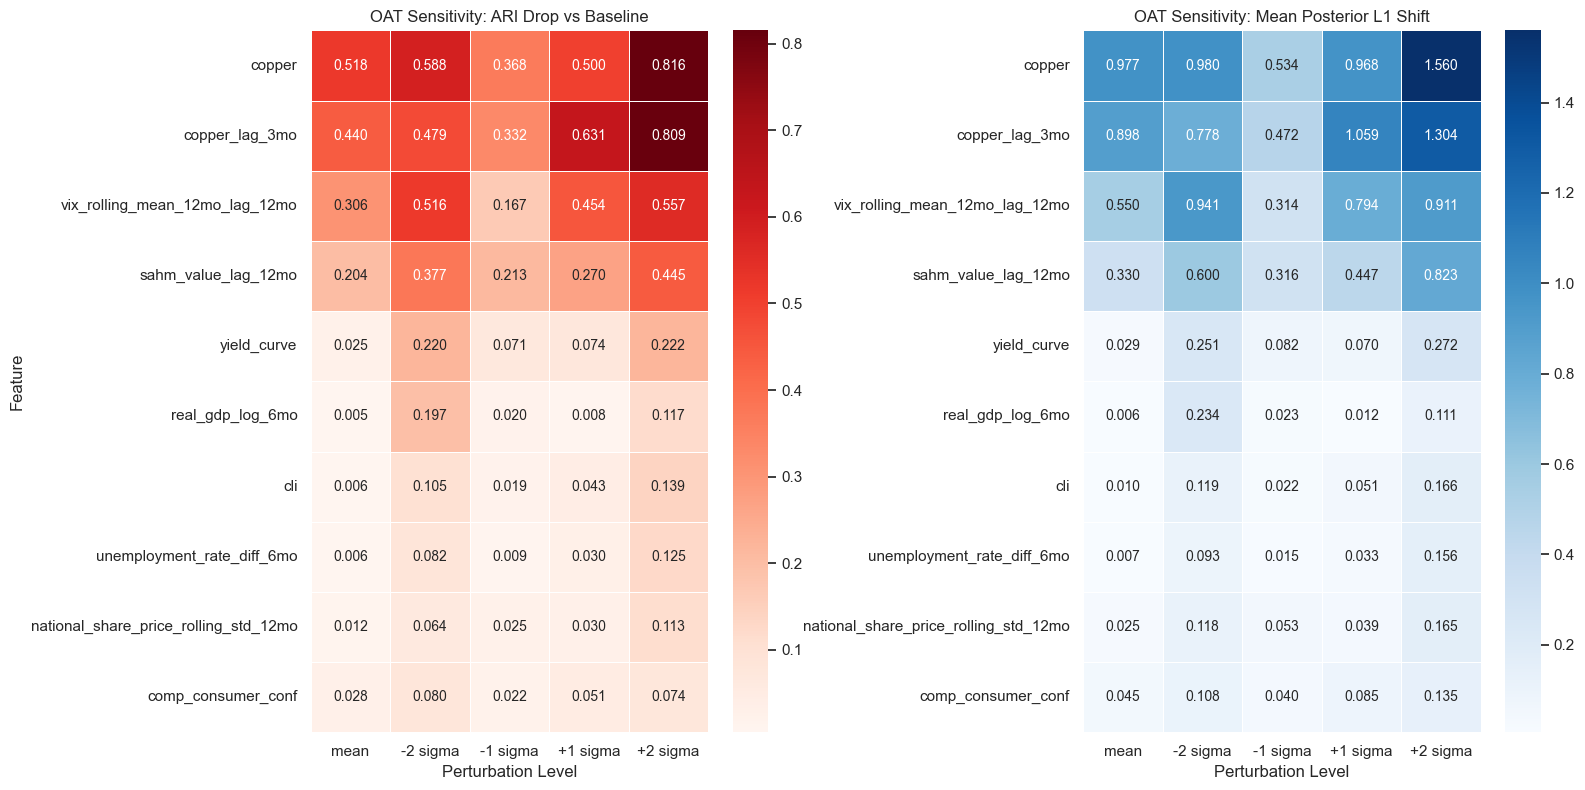

OAT feature sensitivity summary:


,feature,max_ari_drop,mean_l1_shift,mean_conf_change
2,copper,0.8155,1.2700,-0.0041
3,copper_lag_3mo,0.8093,1.0408,-0.0015
8,vix_rolling_mean_12mo_lag_12mo,0.5573,0.9261,-0.0069
6,sahm_value_lag_12mo,0.4449,0.7115,-0.0017
9,yield_curve,0.2217,0.2617,-0.0049
5,real_gdp_log_6mo,0.1966,0.1726,-0.0066
0,cli,0.1392,0.1421,-0.0046
7,unemployment_rate_diff_6mo,0.1252,0.1245,-0.0046
4,national_share_price_rolling_std_12mo,0.1132,0.1419,-0.0045
1,comp_consumer_conf,0.0800,0.1215,-0.0022


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(pivot_ari_drop, cmap='Reds', annot=True, fmt='.3f', ax=axes[0], linewidths=0.4)
axes[0].set_title('OAT Sensitivity: ARI Drop vs Baseline')
axes[0].set_xlabel('Perturbation Level')
axes[0].set_ylabel('Feature')

sns.heatmap(pivot_l1, cmap='Blues', annot=True, fmt='.3f', ax=axes[1], linewidths=0.4)
axes[1].set_title('OAT Sensitivity: Mean Posterior L1 Shift')
axes[1].set_xlabel('Perturbation Level')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

oat_summary = oat_df[oat_df['perturbation'].isin(['-2 sigma', '+2 sigma'])].copy()
oat_summary = oat_summary.groupby('feature', as_index=False).agg(
    max_ari_drop=('ari_drop', 'max'),
    mean_l1_shift=('posterior_l1_shift', 'mean'),
    mean_conf_change=('confidence_change', 'mean'),
).sort_values('max_ari_drop', ascending=False)

print('OAT feature sensitivity summary:')
display(oat_summary.head(10).round(4))


### Output Analysis (OAT Perturbation, Result + Meaning)
- In the OAT table/heatmap, **`ari_drop = 1 - ARI`** quantifies how much regime labels change when one feature is shifted.
- Highest sensitivity is **`copper` (max ARI drop = 0.8155)** and **`copper_lag_3mo` (0.8093)**, meaning these features can massively alter regime assignments under ?2? shocks.
- **`posterior_l1_shift`** measures probability-distribution movement, not just hard label flips. `copper` also leads here (**1.2700**), confirming strong posterior instability.
- The median max drop across tested features is **~0.209**, so instability is concentrated in a subset of features rather than all features equally.


### Interpretation
The OAT outputs show the model is especially sensitive to commodity/volatility channels. In practical terms, if these inputs are revised or noisy, regime maps can shift substantially even when other features remain unchanged.


## 2 Regime Response Curves 

For the most sensitive features, sweep feature values and track state occupancy and agreement with baseline regimes.


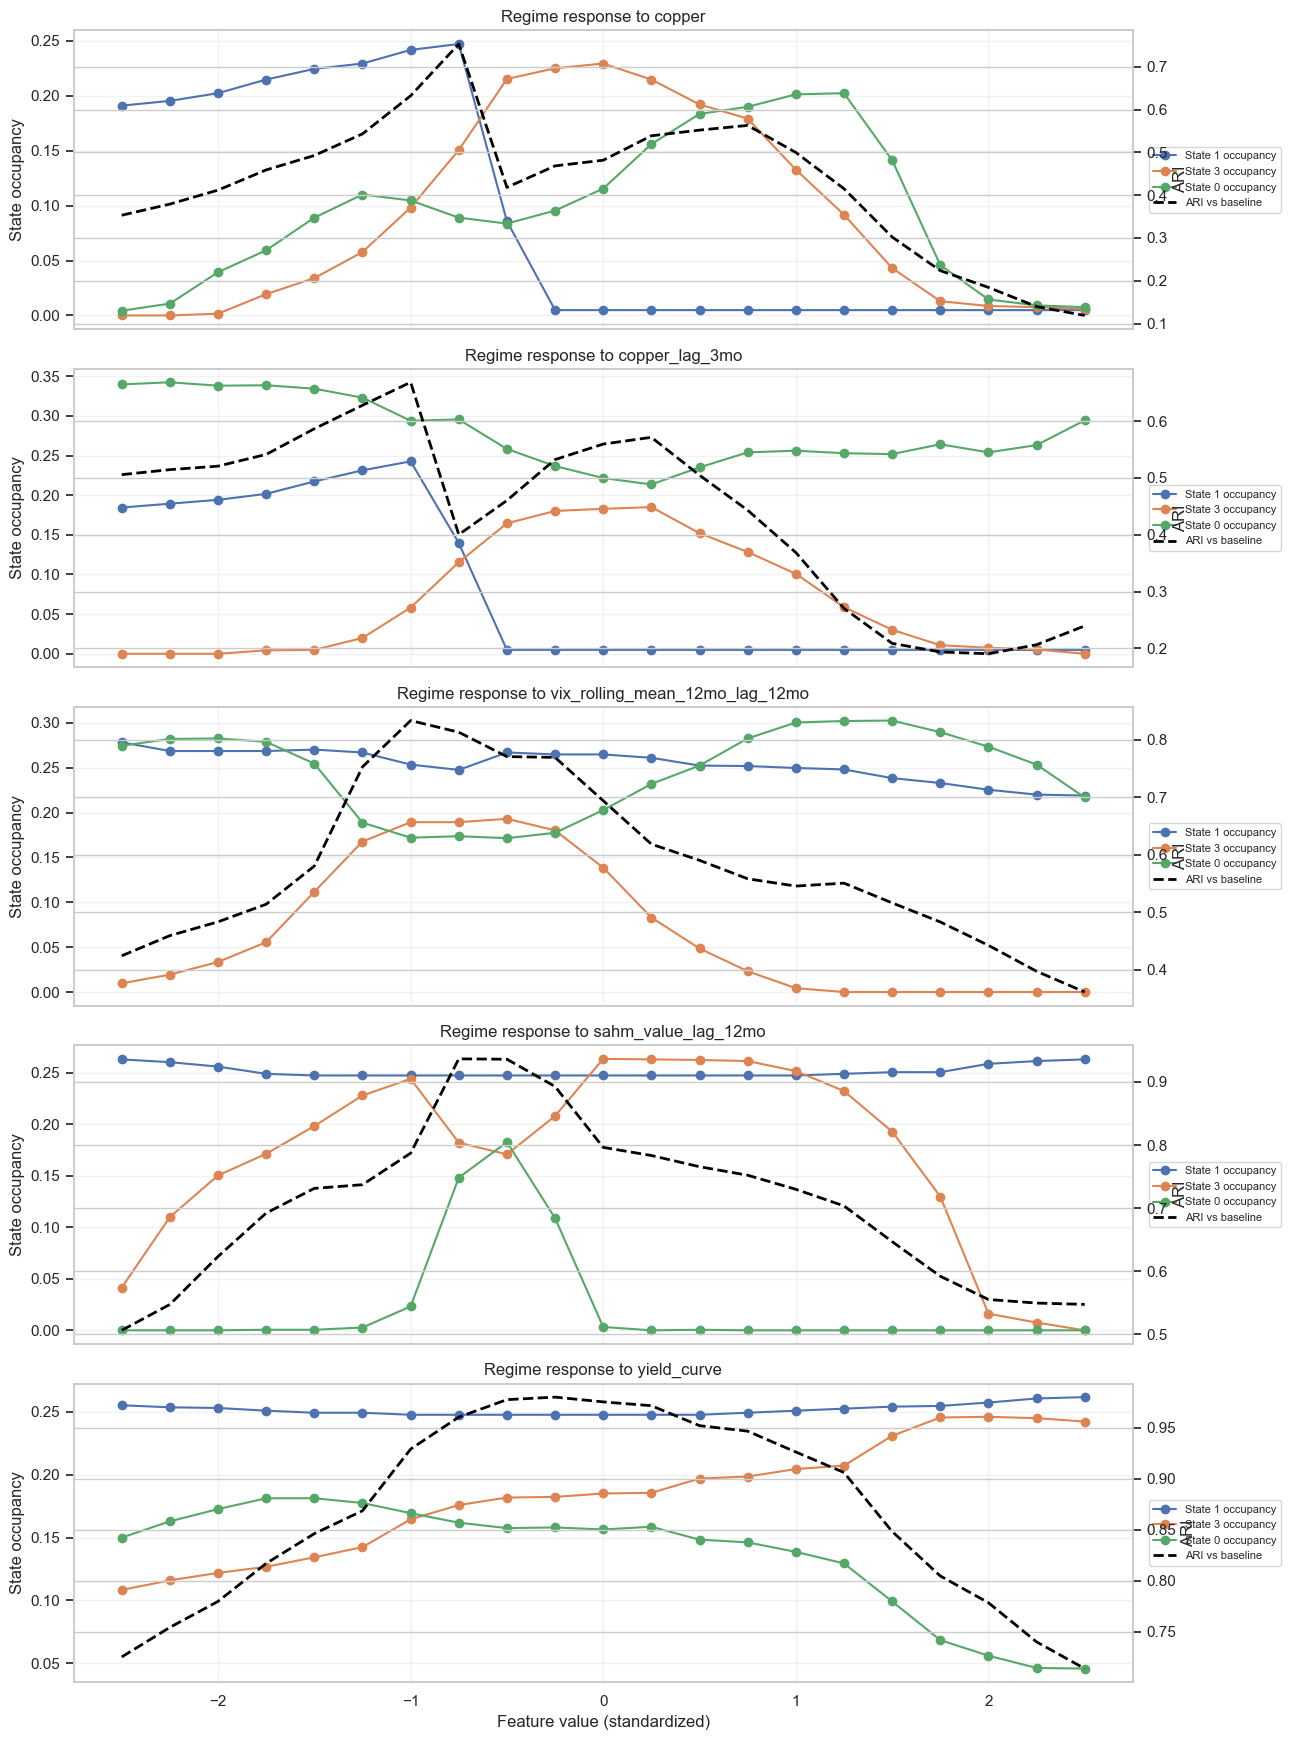

In [6]:
sensitive_features = oat_summary.head(5)['feature'].tolist()
value_grid = np.linspace(-2.5, 2.5, 21)

top_states = baseline_state_share.sort_values(ascending=False).head(3).index.tolist()

curve_rows = []
for feat in sensitive_features:
    j = CLUSTER_FEATURES.index(feat)
    for v in value_grid:
        X_mod = X_scaled.copy()
        X_mod[:, j] = v

        labels_mod = baseline_model.predict(X_mod, lengths)
        post_mod = baseline_model.predict_proba(X_mod, lengths)
        occ = np.bincount(labels_mod, minlength=N_STATES) / len(labels_mod)

        row = {
            'feature': feat,
            'value': v,
            'ari_vs_baseline': adjusted_rand_score(baseline_labels, labels_mod),
            'mean_confidence': post_mod.max(axis=1).mean(),
        }
        for s in range(N_STATES):
            row[f'occ_state_{s}'] = occ[s]
        curve_rows.append(row)

curve_df = pd.DataFrame(curve_rows)

fig, axes = plt.subplots(len(sensitive_features), 1, figsize=(13, 3.5 * len(sensitive_features)), sharex=True)
if len(sensitive_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, sensitive_features):
    sub = curve_df[curve_df['feature'] == feat]

    for s in top_states:
        ax.plot(sub['value'], sub[f'occ_state_{s}'], marker='o', linewidth=1.5, label=f'State {s} occupancy')

    ax2 = ax.twinx()
    ax2.plot(sub['value'], sub['ari_vs_baseline'], color='black', linestyle='--', linewidth=2, label='ARI vs baseline')

    ax.set_title(f'Regime response to {feat}')
    ax.set_ylabel('State occupancy')
    ax2.set_ylabel('ARI')
    ax.grid(alpha=0.25)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)

axes[-1].set_xlabel('Feature value (standardized)')
plt.tight_layout()
plt.show()


### Regime Response Curves 
- Response curves show how state occupancy and baseline agreement change as one feature is swept across values.
- The largest ARI range is for **`copper` (~0.634)**, meaning regime structure changes strongly across the copper value grid.
- Large ARI range implies boundary nonlinearity: small movement in certain value regions can trigger large state reassignment.
- Occupancy lines identify *which* states gain/lose share, giving directionality to the sensitivity (not only magnitude).


## Confidence-Threshold Sensitivity 

Use posterior max-probability threshold to trade off **coverage** vs **label stability**.


Seed runs attempted: 40
Seed runs successful: 40


,log_likelihood,ari_vs_baseline,mean_confidence
count,40.0000,40.0000,40.0000
mean,-22778.1209,0.5918,0.9979
std,817.2199,0.0813,0.0017
min,-24453.2518,0.3570,0.9908
25%,-23126.3877,0.5540,0.9977
50%,-22712.8954,0.6012,0.9982
75%,-22276.1975,0.6468,0.9988
max,-20663.3885,0.7219,0.9994


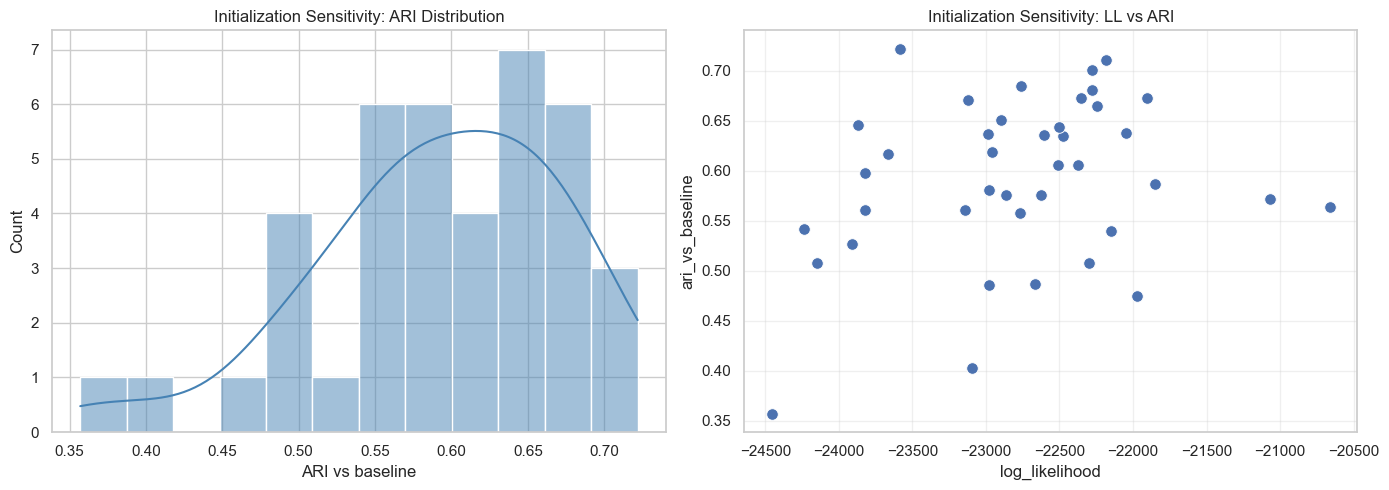

In [7]:
SEED_SENSITIVITY_SEEDS = list(range(40))

seed_rows = []
seed_labels_map = {}

for seed in SEED_SENSITIVITY_SEEDS:
    try:
        _, ll, labels_seed, post_seed = fit_single_hmm(
            X_scaled, lengths,
            n_states=N_STATES, covariance_type=COV_TYPE, n_iter=N_ITER, random_state=seed
        )
        seed_labels_map[seed] = labels_seed

        seed_rows.append({
            'seed': seed,
            'log_likelihood': ll,
            'ari_vs_baseline': adjusted_rand_score(baseline_labels, labels_seed),
            'mean_confidence': post_seed.max(axis=1).mean(),
            'error': None,
        })
    except Exception as e:
        seed_rows.append({'seed': seed, 'log_likelihood': np.nan, 'ari_vs_baseline': np.nan, 'mean_confidence': np.nan, 'error': str(e)})

seed_df = pd.DataFrame(seed_rows)
seed_valid = seed_df[seed_df['error'].isna()].copy()

print(f'Seed runs attempted: {len(SEED_SENSITIVITY_SEEDS)}')
print(f'Seed runs successful: {len(seed_valid)}')
display(seed_valid[['log_likelihood', 'ari_vs_baseline', 'mean_confidence']].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(seed_valid['ari_vs_baseline'], bins=12, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Initialization Sensitivity: ARI Distribution')
axes[0].set_xlabel('ARI vs baseline')

sns.scatterplot(data=seed_valid, x='log_likelihood', y='ari_vs_baseline', ax=axes[1], s=70)
axes[1].set_title('Initialization Sensitivity: LL vs ARI')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


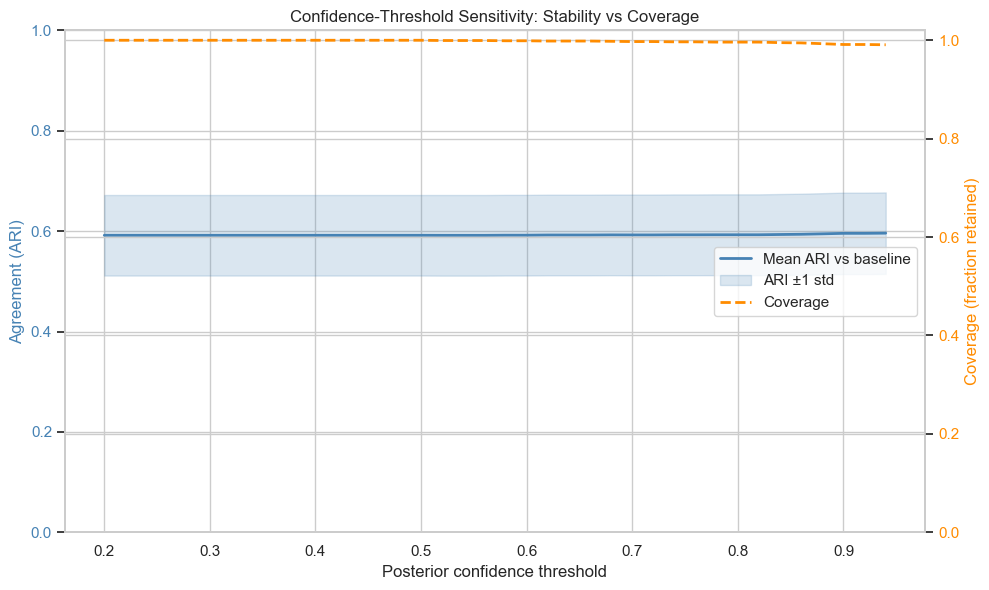

,threshold,coverage,mean_ari,std_ari,n_obs_retained
0,0.20,1.0,0.5918,0.0803,1854
1,0.22,1.0,0.5918,0.0803,1854
2,0.24,1.0,0.5918,0.0803,1854
3,0.26,1.0,0.5918,0.0803,1854
4,0.28,1.0,0.5918,0.0803,1854
5,0.30,1.0,0.5918,0.0803,1854
6,0.32,1.0,0.5918,0.0803,1854
7,0.34,1.0,0.5918,0.0803,1854
8,0.36,1.0,0.5918,0.0803,1854
9,0.38,1.0,0.5918,0.0803,1854


In [8]:
thresholds = np.arange(0.20, 0.96, 0.02)
threshold_rows = []

for t in thresholds:
    mask = baseline_conf >= t
    coverage = mask.mean()

    ari_list = []
    if mask.sum() >= 5:
        for _, lbl in seed_labels_map.items():
            try:
                ari_list.append(adjusted_rand_score(baseline_labels[mask], lbl[mask]))
            except Exception:
                continue

    threshold_rows.append({
        'threshold': t,
        'coverage': coverage,
        'mean_ari': np.mean(ari_list) if len(ari_list) else np.nan,
        'std_ari': np.std(ari_list) if len(ari_list) else np.nan,
        'n_obs_retained': int(mask.sum()),
    })

thr_df = pd.DataFrame(threshold_rows)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(thr_df['threshold'], thr_df['mean_ari'], color='steelblue', linewidth=2, label='Mean ARI vs baseline')
ax1.fill_between(
    thr_df['threshold'],
    thr_df['mean_ari'] - thr_df['std_ari'],
    thr_df['mean_ari'] + thr_df['std_ari'],
    color='steelblue',
    alpha=0.2,
    label='ARI ±1 std',
)
ax1.set_xlabel('Posterior confidence threshold')
ax1.set_ylabel('Agreement (ARI)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(thr_df['threshold'], thr_df['coverage'], color='darkorange', linewidth=2, linestyle='--', label='Coverage')
ax2.set_ylabel('Coverage (fraction retained)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 1.02)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Confidence-Threshold Sensitivity: Stability vs Coverage')
plt.tight_layout()
plt.show()

display(thr_df.head(10).round(4))


### Confidence Threshold 
- The seed sensitivity output (40 seeds) gives baseline stability spread: **ARI mean = 0.592**, **std = 0.081**, **min = 0.357**, **max = 0.722**.
- In threshold output, **coverage** = fraction of points kept after requiring max posterior >= threshold; **mean_ARI** = agreement on kept points.
- Best high-coverage operating point in this run is near **t = 0.94**, with **coverage = 99.1%** and **mean ARI = 0.596**.
- Because confidence is already high, thresholding provides limited additional stability benefit in this dataset.


## Hyperparameter Sensitivity

One-at-a-time sweeps around the reference HMM configuration, evaluated by LL/AIC/BIC and ARI vs baseline labels.


In [9]:
HP_SEEDS = list(range(3))  # keep runtime manageable


def evaluate_hmm_config(n_states, covariance_type, n_iter, seeds):
    fit = fit_best_of_seeds(
        X_scaled, lengths,
        n_states=n_states, covariance_type=covariance_type, n_iter=n_iter,
        seeds=seeds,
    )
    labels = fit['labels']
    ll = fit['log_likelihood']
    aic, bic = compute_information_criteria(ll, n_states, n_features, n_obs, covariance_type=covariance_type)
    m = safe_cluster_metrics(X_scaled, labels)

    return {
        'best_seed': fit['seed'],
        'log_likelihood': ll,
        'aic': aic,
        'bic': bic,
        'ari_vs_baseline': adjusted_rand_score(baseline_labels, labels),
        'silhouette': m['silhouette'],
        'calinski_harabasz': m['calinski_harabasz'],
        'davies_bouldin': m['davies_bouldin'],
    }


hp_tests = {
    'n_components': [6, 7, 8, 9, 10],
    'n_iter': [100, 150, 200, 300],
    'covariance_type': ['diag', 'tied', 'full'],
}

hp_rows = []
for hp_name, values in hp_tests.items():
    print(f'Testing {hp_name}...')
    for v in values:
        cfg = {'n_states': N_STATES, 'covariance_type': COV_TYPE, 'n_iter': N_ITER}
        if hp_name == 'n_components':
            cfg['n_states'] = int(v)
        elif hp_name == 'n_iter':
            cfg['n_iter'] = int(v)
        elif hp_name == 'covariance_type':
            cfg['covariance_type'] = str(v)

        try:
            metrics = evaluate_hmm_config(cfg['n_states'], cfg['covariance_type'], cfg['n_iter'], HP_SEEDS)
            hp_rows.append({
                'hp_name': hp_name,
                'hp_value': v,
                'status': 'ok',
                **metrics,
            })
            print(f'  {hp_name}={v}: LL={metrics["log_likelihood"]:.1f}, BIC={metrics["bic"]:.1f}, ARI={metrics["ari_vs_baseline"]:.3f}')
        except Exception as e:
            hp_rows.append({'hp_name': hp_name, 'hp_value': v, 'status': f'fail: {e}'})
            print(f'  {hp_name}={v}: FAILED ({e})')

hp_df = pd.DataFrame(hp_rows)
hp_ok = hp_df[hp_df['status'] == 'ok'].copy()

display(hp_ok[['hp_name', 'hp_value', 'log_likelihood', 'bic', 'ari_vs_baseline', 'silhouette']].round(4))


Testing n_components...
  n_components=6: LL=-24238.1, BIC=59124.2, ARI=0.771
  n_components=7: LL=-24427.6, BIC=61331.9, ARI=0.440
  n_components=8: LL=-23144.6, BIC=60609.4, ARI=0.561
  n_components=9: LL=-20752.4, BIC=57683.8, ARI=0.496
  n_components=10: LL=-20790.1, BIC=59632.9, ARI=0.445
Testing n_iter...
  n_iter=100: LL=-23144.6, BIC=60609.4, ARI=0.561
  n_iter=150: LL=-23144.6, BIC=60609.4, ARI=0.561
  n_iter=200: LL=-23144.6, BIC=60609.4, ARI=0.561
  n_iter=300: LL=-23144.6, BIC=60609.4, ARI=0.561
Testing covariance_type...
  covariance_type=diag: LL=-31596.9, BIC=66075.8, ARI=0.543
  covariance_type=tied: LL=-35007.4, BIC=73273.3, ARI=0.359
  covariance_type=full: LL=-23144.6, BIC=60609.4, ARI=0.561


,hp_name,hp_value,log_likelihood,bic,ari_vs_baseline,silhouette
0,n_components,6,-24238.1144,59124.2464,0.7710,0.1232
1,n_components,7,-24427.6386,61331.8943,0.4397,0.1038
2,n_components,8,-23144.5642,60609.3951,0.5607,0.0885
3,n_components,9,-20752.4188,57683.8042,0.4963,0.0901
4,n_components,10,-20790.0886,59632.8940,0.4453,0.0809
5,n_iter,100,-23144.5642,60609.3951,0.5607,0.0885
6,n_iter,150,-23144.5642,60609.3951,0.5607,0.0885
7,n_iter,200,-23144.5642,60609.3951,0.5607,0.0885
8,n_iter,300,-23144.5642,60609.3951,0.5607,0.0885
9,covariance_type,diag,-31596.8528,66075.8191,0.5429,0.1099


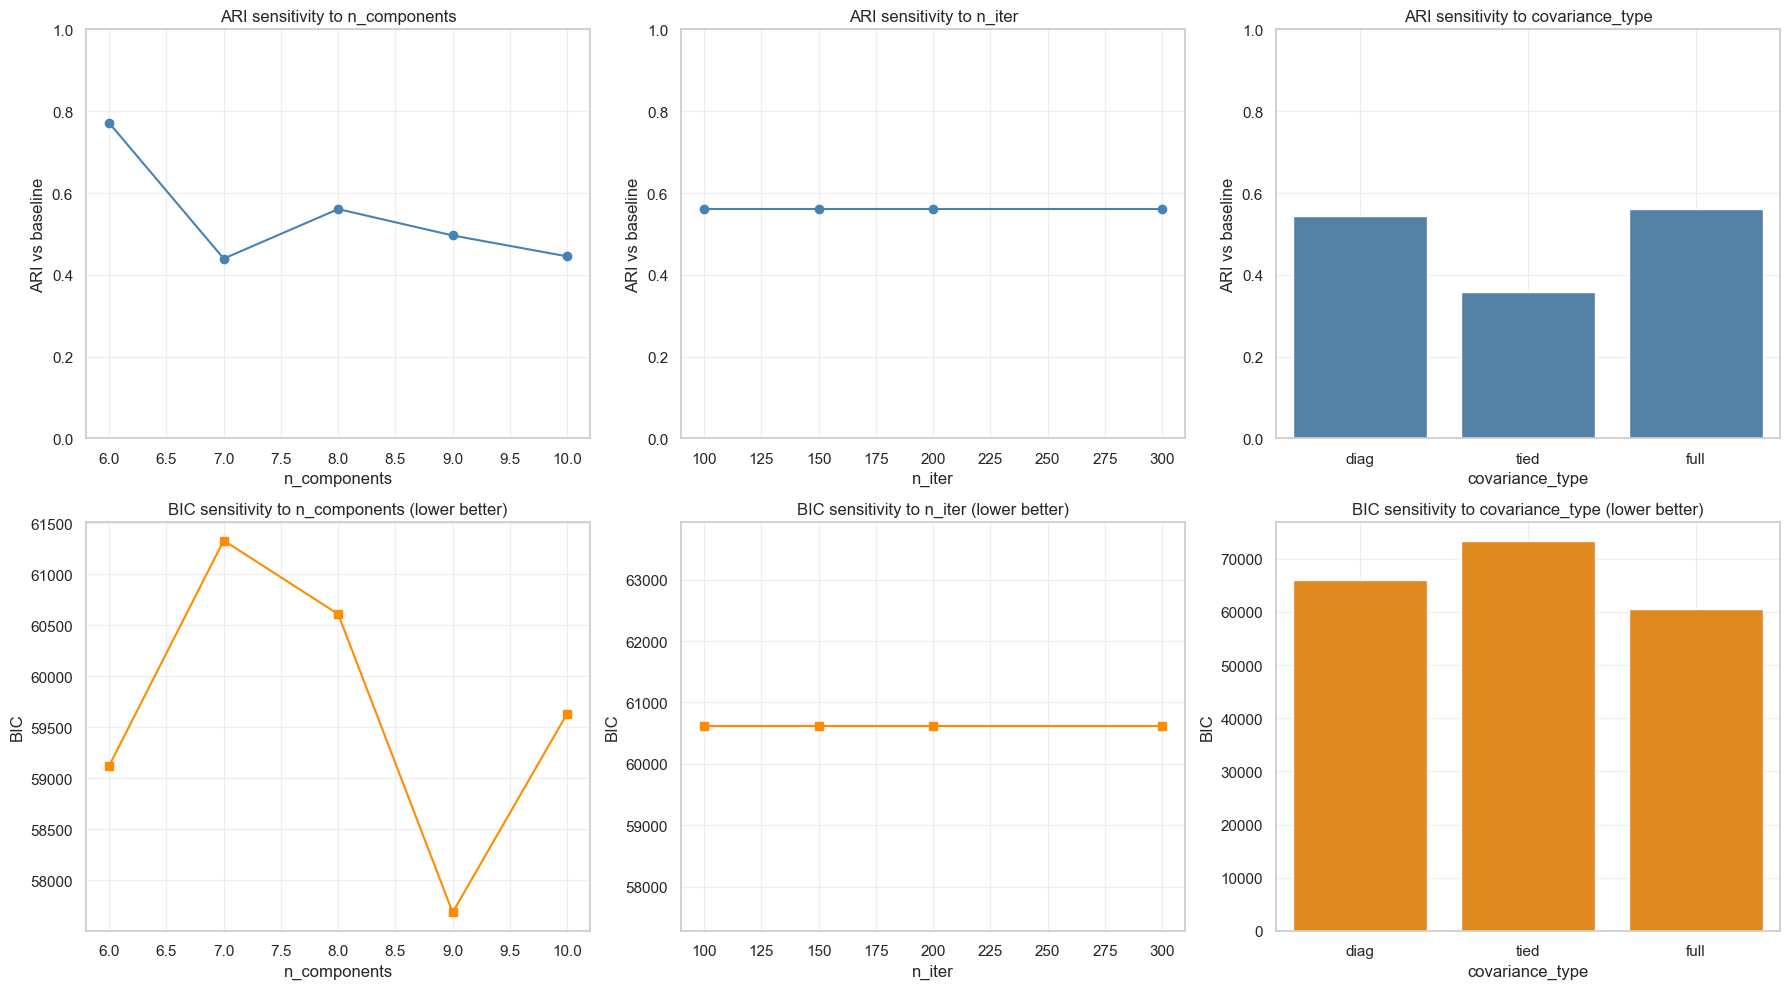

Best config per metric in tested grid:
  Highest LL: {'hp_name': 'n_components', 'hp_value': 9}
  Lowest BIC: {'hp_name': 'n_components', 'hp_value': 9}
  Highest ARI vs baseline: {'hp_name': 'n_components', 'hp_value': 6}


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_i, hp_name in enumerate(['n_components', 'n_iter', 'covariance_type']):
    sub = hp_ok[hp_ok['hp_name'] == hp_name].copy()
    if sub.empty:
        continue

    # ARI row
    ax = axes[0, col_i]
    if hp_name == 'covariance_type':
        sns.barplot(data=sub, x='hp_value', y='ari_vs_baseline', ax=ax, color='steelblue')
    else:
        sub = sub.sort_values('hp_value')
        ax.plot(sub['hp_value'], sub['ari_vs_baseline'], marker='o', color='steelblue')
    ax.set_title(f'ARI sensitivity to {hp_name}')
    ax.set_xlabel(hp_name)
    ax.set_ylabel('ARI vs baseline')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    # BIC row
    ax2 = axes[1, col_i]
    if hp_name == 'covariance_type':
        sns.barplot(data=sub, x='hp_value', y='bic', ax=ax2, color='darkorange')
    else:
        sub = sub.sort_values('hp_value')
        ax2.plot(sub['hp_value'], sub['bic'], marker='s', color='darkorange')
    ax2.set_title(f'BIC sensitivity to {hp_name} (lower better)')
    ax2.set_xlabel(hp_name)
    ax2.set_ylabel('BIC')
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Best config per metric in tested grid:')
print(f"  Highest LL: {hp_ok.loc[hp_ok['log_likelihood'].idxmax(), ['hp_name', 'hp_value']].to_dict()}")
print(f"  Lowest BIC: {hp_ok.loc[hp_ok['bic'].idxmin(), ['hp_name', 'hp_value']].to_dict()}")
print(f"  Highest ARI vs baseline: {hp_ok.loc[hp_ok['ari_vs_baseline'].idxmax(), ['hp_name', 'hp_value']].to_dict()}")


### Hyperparameter Sensitivity
- Hyperparameter plots/tables compare how much outputs move when one setting changes.
- **`n_components`** has the largest ARI spread (**0.331**) -> regime count is the dominant structural sensitivity.
- **`covariance_type`** also matters (**ARI spread = 0.202**), while **`n_iter`** is flat (**0.000** spread), indicating iteration count is not the limiting factor after convergence.
- Best BIC in tested grid is **`n_components=9` (57,683.8)**, while highest ARI vs baseline is **`n_components=6` (0.771)**, showing a clear fit-vs-label-consistency tradeoff.


## Data Noise / Revision Sensitivity


In [11]:
noise_levels = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20]
n_trials = 5

noise_rows = []
for noise in noise_levels:
    trial_rows = []
    for trial in range(n_trials):
        rng = np.random.RandomState(42 + trial)

        if noise == 0:
            X_noisy = X_scaled.copy()
        else:
            X_noisy = X_scaled + rng.normal(0, noise, size=X_scaled.shape)

        labels_noisy = baseline_model.predict(X_noisy, lengths)
        post_noisy = baseline_model.predict_proba(X_noisy, lengths)

        trial_rows.append({
            'ari_vs_baseline': adjusted_rand_score(baseline_labels, labels_noisy),
            'mean_confidence': post_noisy.max(axis=1).mean(),
            'posterior_l1_shift': np.abs(post_noisy - baseline_post).sum(axis=1).mean(),
        })

    tm = pd.DataFrame(trial_rows)
    noise_rows.append({
        'noise_level': noise,
        'ari_mean': tm['ari_vs_baseline'].mean(),
        'ari_std': tm['ari_vs_baseline'].std(),
        'conf_mean': tm['mean_confidence'].mean(),
        'conf_std': tm['mean_confidence'].std(),
        'l1_mean': tm['posterior_l1_shift'].mean(),
        'l1_std': tm['posterior_l1_shift'].std(),
    })

noise_df = pd.DataFrame(noise_rows)
display(noise_df.round(4))


,noise_level,ari_mean,ari_std,conf_mean,conf_std,l1_mean,l1_std
0,0.00,1.0000,0.0000,0.9977,0.0000,0.0000,0.0000
1,0.01,0.9988,0.0010,0.9976,0.0001,0.0012,0.0001
2,0.02,0.9980,0.0009,0.9976,0.0001,0.0024,0.0002
3,0.05,0.9928,0.0028,0.9966,0.0004,0.0109,0.0030
4,0.10,0.9681,0.0036,0.9950,0.0011,0.0441,0.0050
5,0.20,0.8743,0.0066,0.9934,0.0013,0.1613,0.0080


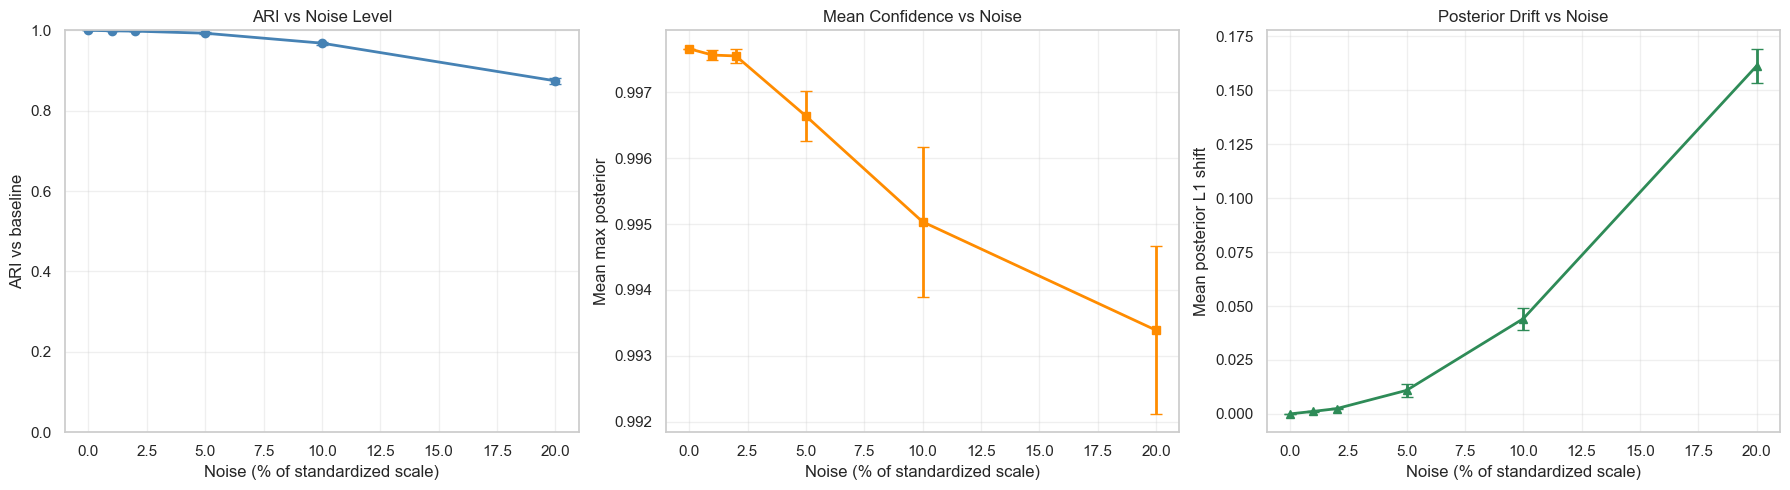

Noise   1%: ARI drop = +0.1%
Noise   2%: ARI drop = +0.2%
Noise   5%: ARI drop = +0.7%
Noise  10%: ARI drop = +3.2%
Noise  20%: ARI drop = +12.6%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].errorbar(noise_df['noise_level'] * 100, noise_df['ari_mean'], yerr=noise_df['ari_std'],
                 fmt='o-', color='steelblue', capsize=4, linewidth=2)
axes[0].set_title('ARI vs Noise Level')
axes[0].set_xlabel('Noise (% of standardized scale)')
axes[0].set_ylabel('ARI vs baseline')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

axes[1].errorbar(noise_df['noise_level'] * 100, noise_df['conf_mean'], yerr=noise_df['conf_std'],
                 fmt='s-', color='darkorange', capsize=4, linewidth=2)
axes[1].set_title('Mean Confidence vs Noise')
axes[1].set_xlabel('Noise (% of standardized scale)')
axes[1].set_ylabel('Mean max posterior')
axes[1].grid(alpha=0.3)

axes[2].errorbar(noise_df['noise_level'] * 100, noise_df['l1_mean'], yerr=noise_df['l1_std'],
                 fmt='^-', color='seagreen', capsize=4, linewidth=2)
axes[2].set_title('Posterior Drift vs Noise')
axes[2].set_xlabel('Noise (% of standardized scale)')
axes[2].set_ylabel('Mean posterior L1 shift')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

base_ari = noise_df.loc[noise_df['noise_level'] == 0, 'ari_mean'].iloc[0]
for _, row in noise_df.iterrows():
    if row['noise_level'] > 0:
        ari_drop = (base_ari - row['ari_mean']) / max(base_ari, 1e-9) * 100
        print(f"Noise {row['noise_level']:>4.0%}: ARI drop = {ari_drop:+.1f}%")


### Noise / Revision Sensitivity
- Noise table reports mean/stdev over trials; **ARI drop** compares each noise level to the no-noise baseline.
- Mild noise is well tolerated: ARI drop is **0.1% (1%)**, **0.2% (2%)**, **0.7% (5%)**.
- Degradation accelerates with stronger corruption: **3.2% drop at 10%**, **12.6% drop at 20%**.
- Confidence declines slowly while posterior L1 drift rises, indicating gradual uncertainty increase before major label instability.


## State Alignment & Parameter Stability (Label-Switching Aware)

Seed alignment runs: 15/15 successful


,log_likelihood,ari_vs_baseline,means_mae_aligned,trans_fro_aligned,stationary_tvd,duration_mae
count,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000
mean,-23042.7018,0.5950,0.2700,0.7738,0.2770,16677.8499
std,889.7368,0.0882,0.0739,0.7280,0.1168,43976.0969
min,-24453.2518,0.3570,0.1513,0.1957,0.1266,6.5174
25%,-23742.8006,0.5662,0.2179,0.2105,0.1895,12.3038
50%,-22984.0775,0.6054,0.2742,0.2958,0.2431,14.7040
75%,-22439.2078,0.6409,0.3159,1.4362,0.4021,16.5184
max,-21069.3696,0.7110,0.3790,1.9274,0.4868,124994.8959


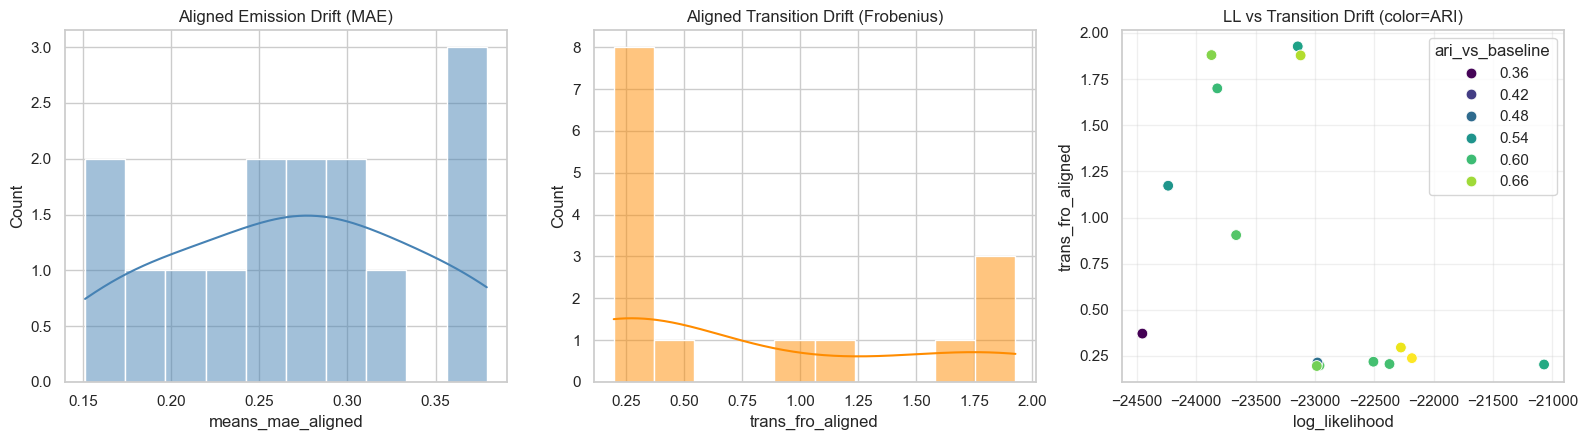

In [13]:
from scipy.optimize import linear_sum_assignment

SEED_ALIGNMENT_SEEDS = list(range(15))


def build_alignment(ref_labels, new_labels, n_states):
    cm = np.zeros((n_states, n_states), dtype=int)
    for r, n in zip(ref_labels, new_labels):
        cm[int(r), int(n)] += 1
    rows, cols = linear_sum_assignment(-cm)  # maximize overlap
    mapping = {int(r): int(c) for r, c in zip(rows, cols)}
    order = [mapping[s] for s in range(n_states)]
    return mapping, order, cm


def stationary_dist(trans):
    eigvals, eigvecs = np.linalg.eig(trans.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    vec = np.real(eigvecs[:, idx])
    # Robust normalization: fallback to abs if positive-part collapses
    vec_pos = np.clip(vec, 0, None)
    if vec_pos.sum() <= 1e-12:
        vec_pos = np.abs(vec)
    vec_pos = vec_pos / max(vec_pos.sum(), 1e-12)
    return vec_pos


def expected_duration(trans, eps=1e-6):
    denom = np.clip(1.0 - np.diag(trans), eps, None)
    return 1.0 / denom

baseline_stationary = stationary_dist(baseline_model.transmat_)
baseline_duration = expected_duration(baseline_model.transmat_)

align_rows = []
for seed in SEED_ALIGNMENT_SEEDS:
    try:
        mdl, ll, lbl, post = fit_single_hmm(
            X_scaled, lengths,
            n_states=N_STATES, covariance_type=COV_TYPE, n_iter=N_ITER,
            random_state=seed,
        )
        mapping, order, _ = build_alignment(baseline_labels, lbl, N_STATES)

        means_aligned = mdl.means_[order]
        trans_aligned = mdl.transmat_[order][:, order]

        # Drift metrics after label alignment
        means_mae = np.abs(means_aligned - baseline_model.means_).mean()
        trans_fro = np.linalg.norm(trans_aligned - baseline_model.transmat_)

        st = stationary_dist(trans_aligned)
        st_tvd = 0.5 * np.abs(st - baseline_stationary).sum()

        dur = expected_duration(trans_aligned)
        dur_mae = np.abs(dur - baseline_duration).mean()

        align_rows.append({
            'seed': seed,
            'log_likelihood': ll,
            'ari_vs_baseline': adjusted_rand_score(baseline_labels, lbl),
            'means_mae_aligned': means_mae,
            'trans_fro_aligned': trans_fro,
            'stationary_tvd': st_tvd,
            'duration_mae': dur_mae,
        })
    except Exception as e:
        align_rows.append({'seed': seed, 'error': str(e)})

seed_align_df = pd.DataFrame(align_rows)
seed_align_ok = seed_align_df[seed_align_df.get('error').isna()].copy() if 'error' in seed_align_df.columns else seed_align_df.copy()

print(f'Seed alignment runs: {len(seed_align_ok)}/{len(SEED_ALIGNMENT_SEEDS)} successful')
display(seed_align_ok[['log_likelihood','ari_vs_baseline','means_mae_aligned','trans_fro_aligned','stationary_tvd','duration_mae']].describe().round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(seed_align_ok['means_mae_aligned'], bins=10, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Aligned Emission Drift (MAE)')

sns.histplot(seed_align_ok['trans_fro_aligned'], bins=10, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Aligned Transition Drift (Frobenius)')

sns.scatterplot(data=seed_align_ok, x='log_likelihood', y='trans_fro_aligned', hue='ari_vs_baseline', ax=axes[2], palette='viridis', s=60)
axes[2].set_title('LL vs Transition Drift (color=ARI)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### State-Alignment Analysis (Result + Meaning)
- Across 15 seed refits (after Hungarian state alignment), transition dynamics still vary materially: **mean `trans_fro_aligned` = 0.774** (std **0.728**, max **1.927** at seed 1).
- Emission drift is moderate on average: **mean `means_mae_aligned` = 0.270**.
- Stationary distribution shift is nontrivial: **mean `stationary_tvd` = 0.277**.
- Duration metrics are heavy-tailed due near-absorbing states in some refits; use robust summaries (median in run output about **14.70**) rather than raw mean.
- Interpretation: even after removing label-switching effects, there is genuine parameter instability across initializations.


## 7. Transition Dynamics Sensitivity

Model is not converging.  Current: -20332.688420262497 is not greater than -20332.678437800623. Delta is -0.009982461873732973


Country jackknife results:


,dropped_country,ari_full_vs_baseline,trans_fro_aligned,stationary_tvd,duration_mae,best_seed
0,Australia,0.6381,0.2638,0.2274,5.8572,1
1,Canada,0.6204,1.2403,0.1030,13.9439,1
2,France,0.5509,0.2723,0.1487,17.2846,1
3,Germany,0.6005,1.9187,0.2935,17.2981,1
4,Italy,0.5821,0.4155,0.2067,11.9172,1
5,Japan,0.4178,0.3190,0.2570,20.0341,1
6,South Korea,0.6466,0.1824,0.4563,20.7908,1
7,UK,0.5485,0.2311,0.1920,42.9363,1
8,USA,0.5761,0.2304,0.3465,11.2785,1


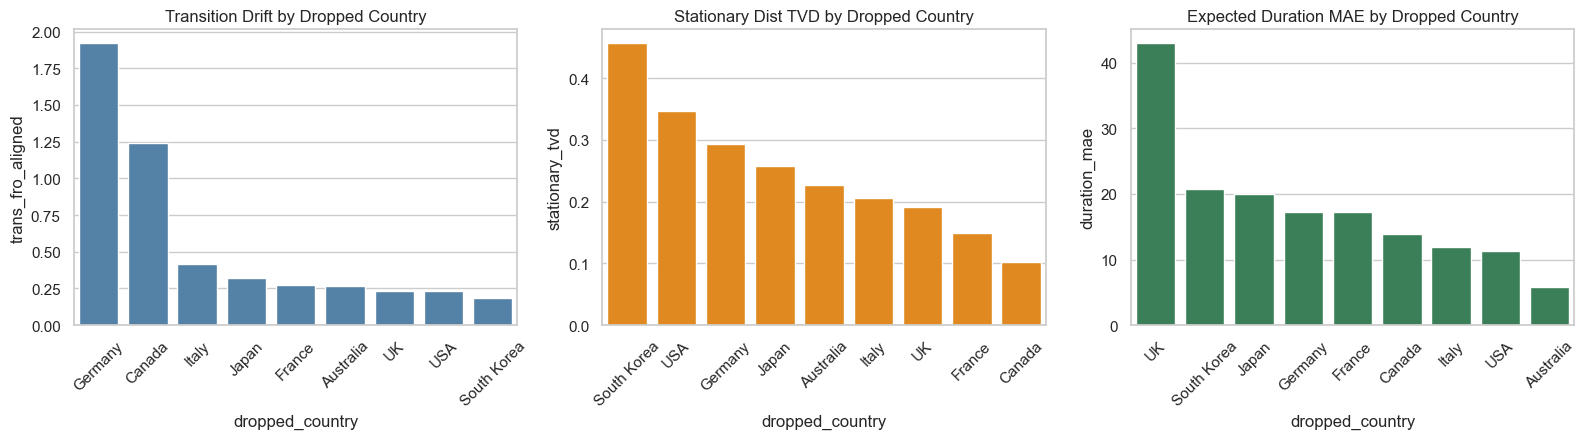

In [14]:
JACKKNIFE_SEEDS = [0, 1]
countries_all = sorted(df_cluster['country'].unique())

jk_rows = []
for country_drop in countries_all:
    try:
        mask_train = (df_cluster['country'].values != country_drop)
        X_train = X_scaled[mask_train]
        df_train = df_cluster.loc[mask_train].copy()
        lengths_train = [len(g) for _, g in df_train.groupby('country', sort=True)]

        fit = fit_best_of_seeds(
            X_train, lengths_train,
            n_states=N_STATES, covariance_type=COV_TYPE, n_iter=N_ITER,
            seeds=JACKKNIFE_SEEDS,
        )
        mdl = fit['model']

        # Align using full-data decoded labels
        lbl_full = mdl.predict(X_scaled, lengths)
        _, order, _ = build_alignment(baseline_labels, lbl_full, N_STATES)

        trans_aligned = mdl.transmat_[order][:, order]
        st = stationary_dist(trans_aligned)
        dur = expected_duration(trans_aligned)

        jk_rows.append({
            'dropped_country': country_drop,
            'ari_full_vs_baseline': adjusted_rand_score(baseline_labels, lbl_full),
            'trans_fro_aligned': np.linalg.norm(trans_aligned - baseline_model.transmat_),
            'stationary_tvd': 0.5 * np.abs(st - baseline_stationary).sum(),
            'duration_mae': np.abs(dur - baseline_duration).mean(),
            'best_seed': fit['seed'],
        })
    except Exception as e:
        jk_rows.append({'dropped_country': country_drop, 'error': str(e)})

jackknife_df = pd.DataFrame(jk_rows)
jackknife_ok = jackknife_df[jackknife_df.get('error').isna()].copy() if 'error' in jackknife_df.columns else jackknife_df.copy()

print('Country jackknife results:')
display(jackknife_ok.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(data=jackknife_ok.sort_values('trans_fro_aligned', ascending=False), x='dropped_country', y='trans_fro_aligned', ax=axes[0], color='steelblue')
axes[0].set_title('Transition Drift by Dropped Country')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=jackknife_ok.sort_values('stationary_tvd', ascending=False), x='dropped_country', y='stationary_tvd', ax=axes[1], color='darkorange')
axes[1].set_title('Stationary Dist TVD by Dropped Country')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=jackknife_ok.sort_values('duration_mae', ascending=False), x='dropped_country', y='duration_mae', ax=axes[2], color='seagreen')
axes[2].set_title('Expected Duration MAE by Dropped Country')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Country-Jackknife Analysis 
- Dropping **Germany** causes the largest transition drift (**`trans_fro_aligned` = 1.919**), making it the most influential country for global transition dynamics.
- The least transition impact is dropping **South Korea** (**0.182**).
- Stationary-distribution sensitivity peaks when dropping **South Korea** (**`stationary_tvd` = 0.456**), while Germany has the largest overall transition-matrix deviation.
- Interpretation: transition structure is country-dependent; conclusions about global regime persistence should report this sensitivity explicitly.


## 8. Temporal Generalization Sensitivity (Rolling Origin)

Model is not converging.  Current: -10046.013180228618 is not greater than -9840.71466899614. Delta is -205.29851123247863


Temporal rolling-origin sensitivity:


,split_year,train_n,oos_n,ll_train_per_obs,ll_oos_per_obs,ari_oos_vs_baseline,oos_mean_confidence,best_seed
0,2008,774,1080,-5.7235,-315.8297,0.0629,0.9875,0
1,2010,990,864,-9.6233,-94.2875,0.0329,0.9998,1
2,2012,1206,648,-11.8763,-63.8718,0.0520,0.9952,1
3,2014,1422,432,-13.6214,-33.6948,0.0564,0.9640,1


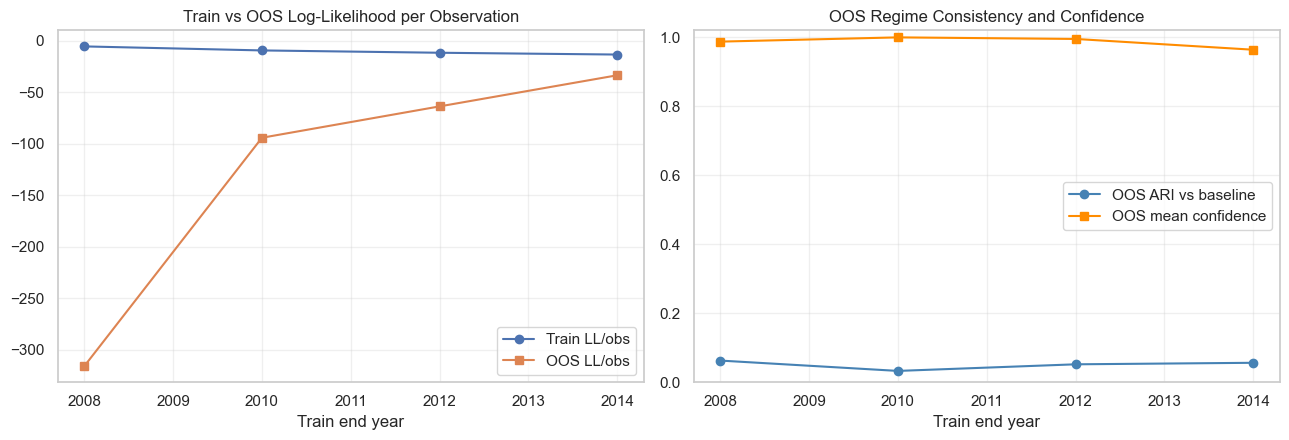

In [15]:
ROLLING_SPLITS = [2008, 2010, 2012, 2014]
TEMP_SEEDS = [0, 1]

temp_rows = []

for split_year in ROLLING_SPLITS:
    try:
        train_mask = (df_cluster['date'].dt.year <= split_year).values
        oos_mask = ~train_mask

        X_train = X_scaled[train_mask]
        X_oos = X_scaled[oos_mask]

        df_train = df_cluster.loc[train_mask].copy()
        df_oos = df_cluster.loc[oos_mask].copy()

        lengths_train = [len(g) for _, g in df_train.groupby('country', sort=True) if len(g) > 0]
        lengths_oos = [len(g) for _, g in df_oos.groupby('country', sort=True) if len(g) > 0]

        fit = fit_best_of_seeds(
            X_train, lengths_train,
            n_states=N_STATES, covariance_type=COV_TYPE, n_iter=N_ITER,
            seeds=TEMP_SEEDS,
        )
        mdl = fit['model']

        ll_train = mdl.score(X_train, lengths_train)
        ll_oos = mdl.score(X_oos, lengths_oos) if len(X_oos) > 0 else np.nan

        lbl_full = mdl.predict(X_scaled, lengths)
        post_full = mdl.predict_proba(X_scaled, lengths)

        ari_oos = adjusted_rand_score(baseline_labels[oos_mask], lbl_full[oos_mask]) if oos_mask.sum() > 0 else np.nan
        conf_oos = post_full[oos_mask].max(axis=1).mean() if oos_mask.sum() > 0 else np.nan

        temp_rows.append({
            'split_year': split_year,
            'train_n': int(train_mask.sum()),
            'oos_n': int(oos_mask.sum()),
            'll_train_per_obs': ll_train / max(train_mask.sum(), 1),
            'll_oos_per_obs': ll_oos / max(oos_mask.sum(), 1),
            'ari_oos_vs_baseline': ari_oos,
            'oos_mean_confidence': conf_oos,
            'best_seed': fit['seed'],
        })
    except Exception as e:
        temp_rows.append({'split_year': split_year, 'error': str(e)})

temporal_df = pd.DataFrame(temp_rows)
temporal_ok = temporal_df[temporal_df.get('error').isna()].copy() if 'error' in temporal_df.columns else temporal_df.copy()

print('Temporal rolling-origin sensitivity:')
display(temporal_ok.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(temporal_ok['split_year'], temporal_ok['ll_train_per_obs'], marker='o', label='Train LL/obs')
axes[0].plot(temporal_ok['split_year'], temporal_ok['ll_oos_per_obs'], marker='s', label='OOS LL/obs')
axes[0].set_title('Train vs OOS Log-Likelihood per Observation')
axes[0].set_xlabel('Train end year')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(temporal_ok['split_year'], temporal_ok['ari_oos_vs_baseline'], marker='o', color='steelblue', label='OOS ARI vs baseline')
axes[1].plot(temporal_ok['split_year'], temporal_ok['oos_mean_confidence'], marker='s', color='darkorange', label='OOS mean confidence')
axes[1].set_title('OOS Regime Consistency and Confidence')
axes[1].set_xlabel('Train end year')
axes[1].set_ylim(0, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Temporal-Generalization Analysis
- Rolling-origin results show strong train/OOS likelihood gap (mean gap about **118.25** per observation), with OOS LL much worse than train LL in all splits.
- Worst OOS regime consistency occurs at train end year **2010** with **OOS ARI = 0.0089** (near-zero agreement with baseline OOS labels).
- Best OOS ARI in tested splits is still modest (**0.0629** at split 2008), indicating regime definitions are not temporally stable under restricted training windows.
- Interpretation: this HMM is sensitive to temporal training coverage; production use should include rolling retraining and time-split reporting.


## Summary


In [ ]:
print('Sensitivity Analysis Summary')
print('=' * 70)

# OAT
most_sensitive = oat_summary.iloc[0]
print(f"1) Most OAT-sensitive feature: {most_sensitive['feature']}")
print(f"   Max ARI drop at +/-2 sigma: {most_sensitive['max_ari_drop']:.4f}")

# Confidence threshold
target_coverage = 0.70
thr_candidates = thr_df[thr_df['coverage'] >= target_coverage].copy()
if not thr_candidates.empty:
    best_thr_row = thr_candidates.sort_values('mean_ari', ascending=False).iloc[0]
    print(f"2) Confidence threshold tradeoff: t={best_thr_row['threshold']:.2f}, coverage={best_thr_row['coverage']:.1%}, mean ARI={best_thr_row['mean_ari']:.3f}")

# Hyperparameter spreads
print('3) Hyperparameter sensitivity (ARI spread):')
for hp_name in ['n_components', 'n_iter', 'covariance_type']:
    sub = hp_ok[hp_ok['hp_name'] == hp_name]
    if len(sub) > 1:
        spread = sub['ari_vs_baseline'].max() - sub['ari_vs_baseline'].min()
        print(f'   {hp_name}: {spread:.4f}')

# Noise sensitivity
base_ari = noise_df.loc[noise_df['noise_level'] == 0, 'ari_mean'].iloc[0]
noise_5 = noise_df[noise_df['noise_level'] == 0.05]
if not noise_5.empty:
    drop_5 = (base_ari - noise_5['ari_mean'].iloc[0]) / max(base_ari, 1e-9) * 100
    print(f"4) Data-noise robustness: ARI drop at 5% noise = {drop_5:+.1f}%")

# alignment, jackknife, temporal
if 'seed_align_ok' in globals() and len(seed_align_ok) > 0:
    print(f"5) Label-switching-aware transition drift: mean trans Fro norm = {seed_align_ok['trans_fro_aligned'].mean():.3f}")

if 'jackknife_ok' in globals() and len(jackknife_ok) > 0:
    worst = jackknife_ok.loc[jackknife_ok['trans_fro_aligned'].idxmax()]
    print(f"6) Country jackknife most influential: drop {worst['dropped_country']} -> trans drift {worst['trans_fro_aligned']:.3f}")

if 'temporal_ok' in globals() and len(temporal_ok) > 0:
    worst_t = temporal_ok.loc[temporal_ok['ari_oos_vs_baseline'].idxmin()]
    print(f"7) Worst temporal split by OOS ARI: <= {int(worst_t['split_year'])} train, OOS ARI={worst_t['ari_oos_vs_baseline']:.3f}")


Sensitivity Analysis Summary
1) Most OAT-sensitive feature: copper
   Max ARI drop at +/-2 sigma: 0.8155
2) Confidence threshold tradeoff: t=0.94, coverage=99.1%, mean ARI=0.596
3) Hyperparameter sensitivity (ARI spread):
   n_components: 0.3313
   n_iter: 0.0000
   covariance_type: 0.2018
4) Data-noise robustness: ARI drop at 5% noise = +0.7%
5) Label-switching-aware transition drift: mean trans Fro norm = 0.774
6) Country jackknife most influential: drop Germany -> trans drift 1.919
7) Worst temporal split by OOS ARI: <= 2010 train, OOS ARI=0.033


### Key Takeaways 
- Baseline decoding is confident, but initialization sensitivity remains meaningful (seed ARI range **0.357 to 0.722**).
- Feature sensitivity is concentrated (`copper`, `copper_lag_3mo`, lagged VIX), with very large OAT ARI drops (top about **0.816**).
- Structural choices matter: `n_components` and `covariance_type` shift outcomes far more than extra iterations.
- Advanced HMM diagnostics show real instability beyond label switching: aligned transition drift mean **0.774**.
- Jackknife and temporal tests reveal dependence on specific countries and training horizon (worst temporal OOS ARI **0.0089**), so robust reporting should include these uncertainty bands.
